In [ ]:
# Standard library
import numpy as np
import copy
import cmasher as cmr
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
from configparser import ConfigParser
from glob import glob
from itertools import permutations
from astropy.io import ascii
from astropy.io import fits
from matplotlib import rc
from scipy import optimize
from scipy.optimize import fsolve

In [2]:
# Load in the vigeesh simulations
path = '/Users/juliomorales/Research/Projects/Vesa_2024/Data/Vigeesh/'

# Collect all data files
files = sorted(glob(path + '*.h5'))

# Empty list to store the data
data = []

# Loop through the files and load them
for file in files:
    # Load the data
    ds = xr.open_dataset(file)
    
    # Append the time averaged data to the list
    data.append(ds)

In [3]:
# All possible pairs of covariances
pairs = np.array(list(permutations(np.arange(0, len(data)), 2)))

# Delete the reversed duplicates
pairs = pairs[pairs[:, 0] < pairs[:, 1]]

In [ ]:
def azimuthal_average(power):

    '''
    Purpose
    -------
    Azimuthally average the 3D solar oscillation power spectrum.

    Inputs
    ------
    [power: np.array, float]:
        3D power spectrum to be azimuthally averaged.

    Outputs
    -------
    [azi_avg_power: np.array, float]:
        Azimuthally averaged power (1st quadrant only).

    Author(s)
    ---------
    Julio M. Morales, October 10, 2022
    '''

    # Set up a meshgrid of radii
    x = np.linspace(0, int(power.shape[2]) - 1, int(power.shape[2]))
    y = np.linspace(0, int(power.shape[1]) - 1, int(power.shape[1]))

    # Extract midopints
    xmid, ymid = int(power.shape[2]/2), int(power.shape[1]/2)
    xx, yy = np.meshgrid(x, y)

    # Define empty list of power array
    avg_power_array = []

    # Loop through all of the slices through temporal frequency
    for freq in range(int(power.shape[0]/2), int(power.shape[0])):

        # Take slice
        freq_slice = power[freq, :, :,]

        # Empty power list to be added to
        avg_power = []

        # Start loop
        for i in range(0, int(power.shape[1]/2)):

            # Create a hypotenuse
            d = np.hypot(xx - xmid, yy - ymid)

            # Create mask
            
            d[np.where((d >= i - 0.5) & (d < i + 0.5))] = 1; d[np.where(d != 1)] = 0

            # NOTE: This method produces a ring of pixels around the center pixel.  The following conditional is to remnedy this
            if (i == 1):
                pass

            else:
                d[int(d.shape[1]/2 + 1), int(d.shape[0]/2)] = d[int(d.shape[1]/2 - 1), int(d.shape[0]/2)] = d[int(d.shape[1]/2), int(d.shape[0]/2 + 1)] = d[int(d.shape[1]/2), int(d.shape[0]/2 - 1)] = 0

            # Apply mask
            masked_image = freq_slice*d

            # Take the average pixel value of the image
            avg_pix = np.nanmean(masked_image)

            # Averaged power
            avg_power.append(avg_pix)

        # Convert list to an array and add to larger array
        avg_power_array.append(np.array(avg_power))

    # Turn list into array
    azi_avg_power = np.array(avg_power_array)

    return np.flipud(azi_avg_power)

In [5]:
def phase_diff(v1, v2):

    '''
    Purpose
    -------
    To calculate the phase difference between two atmospheric heights.

    Parameters
    ----------
    v1 : np.array, float
        The doppler time series at first atmospheric height [x, y, t].

    v2 : np.array, float
        The doppler time series at second atmospheric height [x, y, t].

    Returns
    -------
    phase_diff : np.array, float
        The phase difference between the two heights.

    Author(s)
    ---------
    Julio M. Morales, April 2nd, 2025
    '''

    # FFT of original IBIS products
    fft_lower = np.fft.fftshift(np.fft.fftn(v1))
    fft_higher = np.fft.fftshift(np.fft.fftn(v2))
    
    # Compute the cross power spectra and phase difference spectra
    crosspow = fft_lower * np.conj(fft_higher)
    phasepow = np.angle(crosspow, deg = False)

    # Azimuthal average the phase difference
    azim_phase = azimuthal_average(phasepow)

    # Convert to degrees
    phase_diff = np.rad2deg(azim_phase)

    return phase_diff

In [6]:
# Pull two datasets of two different heights
height1 = data[0]
height2 = data[1]

# Swap the the 2nd and 3rd axis
v1 = np.swapaxes(height1['vz'].data, 1, 2)
v2 = np.swapaxes(height2['vz'].data, 1, 2)

# Calculate the cross_spectrum
phase_sim = phase_diff(v1, v2)

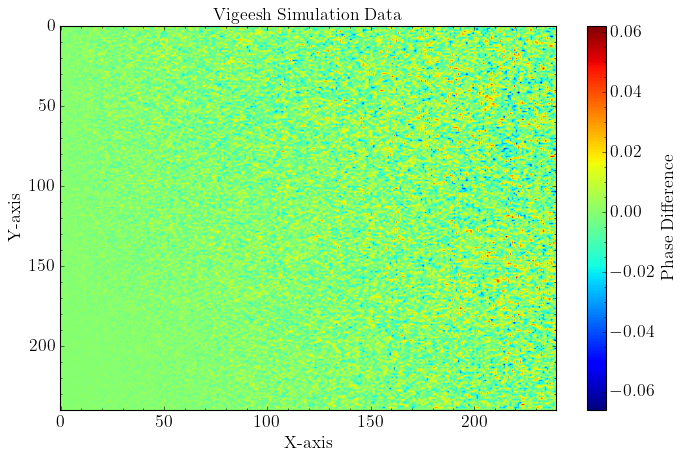

In [ ]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.imshow(((np.real(phase_sim))), aspect ='auto')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Vigeesh Simulation Data')
plt.colorbar(label='Phase Difference')
plt.show()

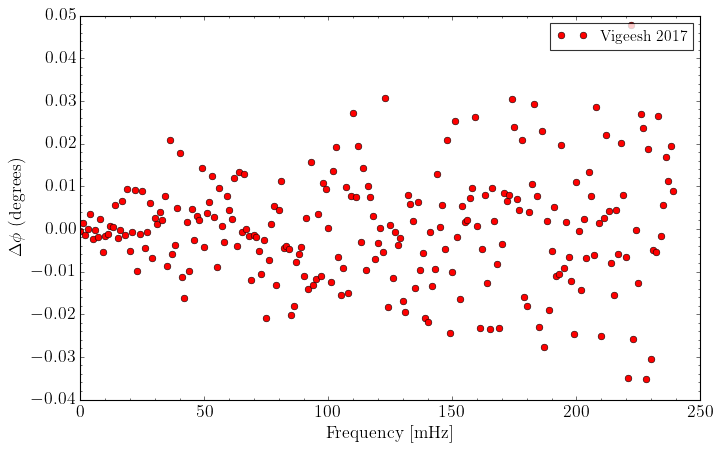

In [16]:
# Plot the Vigeesh simulation phase differences
phase1d_sim = phase_sim[0, :]
# phase1d_mod = phase_mod[:, 0]

# Plot the phase differences as a function of frequency
plt.figure(figsize=(10, 6))
plt.plot(np.arange(0, len(phase1d_sim)), phase1d_sim, 'ro', label='Vigeesh 2017')
# plt.plot(np.arange(0, len(phase1d_mod)), phase1d_mod, 'bo', label='N&C 2010')
plt.xlabel('Frequency [mHz]')
plt.ylabel(r'$\Delta \phi$ (degrees)')
plt.legend()
plt.show()